In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\AIML waterbourne project\datasets\cleaned_datasets\final_complete_waterborne_dataset.csv"
)

df.head()

,Type Water Body,State Name,Min Temperature,Min Dissolved Oxygen,Min pH,Min Conductivity,Min BOD,Min_Nitrate_Nitrite,Min Fecal Coliform,Min Total Coliform,Year,Toilet_Access,Open_Defecation,Rainfall,Risk_Level
0,LAKE,ANDHRA PRADESH,27,5.1,7.1,3270,1.0,0.65,2.0,800,2017,49.6,50.4,80.778387,MEDIUM
1,LAKE,ANDHRA PRADESH,24,5.9,6.9,597,1.3,1.16,11.0,350,2017,49.6,50.4,80.778387,MEDIUM
2,LAKE,ASSAM,20,2.2,5.7,50,1.0,0.1,300.0,360,2017,65.0,35.1,201.048883,MEDIUM
3,LAKE,ASSAM,22,5.1,6.6,54,0.9,0.1,300.0,300,2017,65.0,35.1,201.048883,MEDIUM
4,POND,ASSAM,22,0.7,6.8,263,4.5,0.8,1100.0,730,2017,65.0,35.1,201.048883,HIGH


In [42]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Risk_Level_Encoded'] = label_encoder.fit_transform(
    df['Risk_Level']
)

print(label_encoder.classes_)

df.head()

['HIGH' 'LOW' 'MEDIUM']


,Type Water Body,State Name,Min Temperature,Min Dissolved Oxygen,Min pH,Min Conductivity,Min BOD,Min_Nitrate_Nitrite,Min Fecal Coliform,Min Total Coliform,Year,Toilet_Access,Open_Defecation,Rainfall,Risk_Level,Risk_Level_Encoded
0,LAKE,ANDHRA PRADESH,27,5.1,7.1,3270,1.0,0.65,2.0,800,2017,49.6,50.4,80.778387,MEDIUM,2
1,LAKE,ANDHRA PRADESH,24,5.9,6.9,597,1.3,1.16,11.0,350,2017,49.6,50.4,80.778387,MEDIUM,2
2,LAKE,ASSAM,20,2.2,5.7,50,1.0,0.1,300.0,360,2017,65.0,35.1,201.048883,MEDIUM,2
3,LAKE,ASSAM,22,5.1,6.6,54,0.9,0.1,300.0,300,2017,65.0,35.1,201.048883,MEDIUM,2
4,POND,ASSAM,22,0.7,6.8,263,4.5,0.8,1100.0,730,2017,65.0,35.1,201.048883,HIGH,0


In [43]:
type_encoder = LabelEncoder()

df['Type Water Body'] = type_encoder.fit_transform(
    df['Type Water Body']
)

df.head()

,Type Water Body,State Name,Min Temperature,Min Dissolved Oxygen,Min pH,Min Conductivity,Min BOD,Min_Nitrate_Nitrite,Min Fecal Coliform,Min Total Coliform,Year,Toilet_Access,Open_Defecation,Rainfall,Risk_Level,Risk_Level_Encoded
0,0,ANDHRA PRADESH,27,5.1,7.1,3270,1.0,0.65,2.0,800,2017,49.6,50.4,80.778387,MEDIUM,2
1,0,ANDHRA PRADESH,24,5.9,6.9,597,1.3,1.16,11.0,350,2017,49.6,50.4,80.778387,MEDIUM,2
2,0,ASSAM,20,2.2,5.7,50,1.0,0.1,300.0,360,2017,65.0,35.1,201.048883,MEDIUM,2
3,0,ASSAM,22,5.1,6.6,54,0.9,0.1,300.0,300,2017,65.0,35.1,201.048883,MEDIUM,2
4,1,ASSAM,22,0.7,6.8,263,4.5,0.8,1100.0,730,2017,65.0,35.1,201.048883,HIGH,0


In [44]:
state_encoder = LabelEncoder()

df['State Name'] = state_encoder.fit_transform(
    df['State Name']
)

df.head()

,Type Water Body,State Name,Min Temperature,Min Dissolved Oxygen,Min pH,Min Conductivity,Min BOD,Min_Nitrate_Nitrite,Min Fecal Coliform,Min Total Coliform,Year,Toilet_Access,Open_Defecation,Rainfall,Risk_Level,Risk_Level_Encoded
0,0,0,27,5.1,7.1,3270,1.0,0.65,2.0,800,2017,49.6,50.4,80.778387,MEDIUM,2
1,0,0,24,5.9,6.9,597,1.3,1.16,11.0,350,2017,49.6,50.4,80.778387,MEDIUM,2
2,0,1,20,2.2,5.7,50,1.0,0.1,300.0,360,2017,65.0,35.1,201.048883,MEDIUM,2
3,0,1,22,5.1,6.6,54,0.9,0.1,300.0,300,2017,65.0,35.1,201.048883,MEDIUM,2
4,1,1,22,0.7,6.8,263,4.5,0.8,1100.0,730,2017,65.0,35.1,201.048883,HIGH,0


In [45]:
df.replace('-', np.nan, inplace=True)

numeric_columns = [
    'Min Temperature',
    'Min Dissolved Oxygen',
    'Min pH',
    'Min Conductivity',
    'Min BOD',
    'Min_Nitrate_Nitrite',
    'Min Fecal Coliform',
    'Min Total Coliform',
    'Toilet_Access',
    'Open_Defecation',
    'Rainfall'
]

for col in numeric_columns:

    df[col] = df[col].astype(str)

    df[col] = df[col].str.extract(r'([-+]?\d*\.?\d+)')

    df[col] = pd.to_numeric(df[col], errors='coerce')

    df[col] = df[col].fillna(df[col].mean())


print(df.isnull().sum())

Type Water Body         0
State Name              0
Min Temperature         0
Min Dissolved Oxygen    0
Min pH                  0
Min Conductivity        0
Min BOD                 0
Min_Nitrate_Nitrite     0
Min Fecal Coliform      0
Min Total Coliform      0
Year                    0
Toilet_Access           0
Open_Defecation         0
Rainfall                0
Risk_Level              0
Risk_Level_Encoded      0
dtype: int64


In [46]:
X = df.drop(
    ['Risk_Level', 'Risk_Level_Encoded'],
    axis=1
)

y = df['Risk_Level_Encoded']

print(X.head())

print(y.head())

   Type Water Body  State Name  Min Temperature  Min Dissolved Oxygen  Min pH  \
0                0           0             27.0                   5.1     7.1   
1                0           0             24.0                   5.9     6.9   
2                0           1             20.0                   2.2     5.7   
3                0           1             22.0                   5.1     6.6   
4                1           1             22.0                   0.7     6.8   

   Min Conductivity  Min BOD  Min_Nitrate_Nitrite  Min Fecal Coliform  \
0            3270.0      1.0                 0.65                 2.0   
1             597.0      1.3                 1.16                11.0   
2              50.0      1.0                 0.10               300.0   
3              54.0      0.9                 0.10               300.0   
4             263.0      4.5                 0.80              1100.0   

   Min Total Coliform  Year  Toilet_Access  Open_Defecation    Rainfall  


In [47]:
print((X == '-').sum())

Type Water Body         0
State Name              0
Min Temperature         0
Min Dissolved Oxygen    0
Min pH                  0
Min Conductivity        0
Min BOD                 0
Min_Nitrate_Nitrite     0
Min Fecal Coliform      0
Min Total Coliform      0
Year                    0
Toilet_Access           0
Open_Defecation         0
Rainfall                0
dtype: int64


In [48]:
numeric_df = df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                      Type Water Body  State Name  Min Temperature  \
Type Water Body              1.000000   -0.120664         0.246942   
State Name                  -0.120664    1.000000         0.002407   
Min Temperature              0.246942    0.002407         1.000000   
Min Dissolved Oxygen        -0.009323   -0.113922        -0.272987   
Min pH                      -0.014419    0.076508        -0.096174   
Min Conductivity             0.033058    0.035980         0.095123   
Min BOD                      0.048942    0.114421         0.132707   
Min_Nitrate_Nitrite          0.080320    0.255134         0.108139   
Min Fecal Coliform           0.000849   -0.018648         0.056510   
Min Total Coliform          -0.012487    0.005664         0.036468   
Year                         0.006926    0.060605         0.116474   
Toilet_Access               -0.004926   -0.048400         0.112979   
Open_Defecation              0.005192    0.048113        -0.112432   
Rainfall            

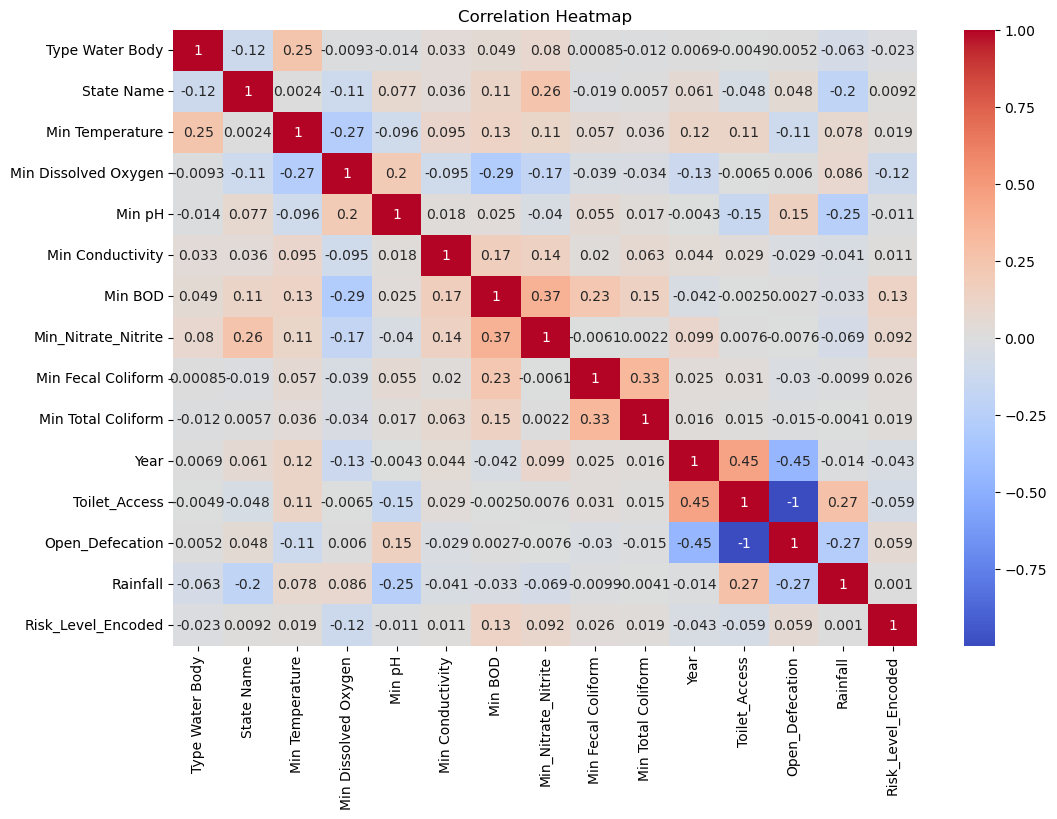

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3030, 14)
(758, 14)
(3030,)
(758,)


In [52]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


c:\Users\Mohammed Abuzar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[2 1 2 1 1 2 2 1 1 2]


In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8258575197889182


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 25   0  37]
 [  0 307  29]
 [ 18  48 294]]


In [56]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Precision : 0.8187539917050316
Recall : 0.8258575197889182
F1 Score : 0.8206892087505631


In [57]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.58      0.40      0.48        62
           1       0.86      0.91      0.89       336
           2       0.82      0.82      0.82       360

    accuracy                           0.83       758
   macro avg       0.75      0.71      0.73       758
weighted avg       0.82      0.83      0.82       758



In [58]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[0.00000000e+00 0.00000000e+00 8.18181818e-01 3.10975610e-01
  7.71739130e-01 1.05144695e-01 9.34579439e-03 1.38297872e-02
  4.00000000e-05 5.71428571e-05 0.00000000e+00 4.60946095e-01
  5.37953795e-01 2.03048094e-01]
 [0.00000000e+00 0.00000000e+00 7.27272727e-01 3.59756098e-01
  7.50000000e-01 1.91961415e-02 1.21495327e-02 2.46808511e-02
  2.20000000e-04 2.50000000e-05 0.00000000e+00 4.60946095e-01
  5.37953795e-01 2.03048094e-01]
 [0.00000000e+00 3.33333333e-02 6.06060606e-01 1.34146341e-01
  6.19565217e-01 1.60771704e-03 9.34579439e-03 2.12765957e-03
  6.00000000e-03 2.57142857e-05 0.00000000e+00 6.30363036e-01
  3.69636964e-01 5.05365282e-01]
 [0.00000000e+00 3.33333333e-02 6.66666667e-01 3.10975610e-01
  7.17391304e-01 1.73633441e-03 8.41121495e-03 2.12765957e-03
  6.00000000e-03 2.14285714e-05 0.00000000e+00 6.30363036e-01
  3.69636964e-01 5.05365282e-01]
 [2.50000000e-01 3.33333333e-02 6.66666667e-01 4.26829268e-02
  7.39130435e-01 8.45659164e-03 4.20560748e-02 1.70212766e-02


In [59]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(cv_scores)

c:\Users\Mohammed Abuzar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Mohammed Abuzar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/prepr

[0.7651715  0.87335092 0.77440633 0.84544254 0.75165125]


c:\Users\Mohammed Abuzar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [60]:
print("Average Cross Validation Score :", cv_scores.mean())

Average Cross Validation Score : 0.8020045102351665


In [61]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [62]:
y_pred_dt = dt_model.predict(X_test)

print(y_pred_dt[:10])

[2 1 2 1 1 2 2 1 1 0]


In [63]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 0.9709762532981531


In [64]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(
    y_test,
    y_pred_dt
)

print(dt_cm)

[[ 58   0   4]
 [  0 331   5]
 [  4   9 347]]


In [65]:
from sklearn.metrics import classification_report

dt_report = classification_report(
    y_test,
    y_pred_dt
)

print(dt_report)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        62
           1       0.97      0.99      0.98       336
           2       0.97      0.96      0.97       360

    accuracy                           0.97       758
   macro avg       0.96      0.96      0.96       758
weighted avg       0.97      0.97      0.97       758



In [66]:
from sklearn.tree import DecisionTreeClassifier

fine_tuned_dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

fine_tuned_dt.fit(X_train, y_train)

print("Fine Tuned Decision Tree Model Trained Successfully")

Fine Tuned Decision Tree Model Trained Successfully


In [67]:
y_pred_fine = fine_tuned_dt.predict(X_test)

print(y_pred_fine[:10])

[2 1 2 1 1 2 2 1 1 0]


In [68]:
fine_accuracy = accuracy_score(
    y_test,
    y_pred_fine
)

print("Fine Tuned Accuracy :", fine_accuracy)

Fine Tuned Accuracy : 0.9709762532981531


In [69]:
import pickle

with open("waterborne_model.pkl", "wb") as file:
    pickle.dump(fine_tuned_dt, file)

with open("type_encoder.pkl", "wb") as file:
    pickle.dump(type_encoder, file)

with open("state_encoder.pkl", "wb") as file:
    pickle.dump(state_encoder, file)

with open("risk_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

feature_columns = X.columns.tolist()

with open("feature_columns.pkl", "wb") as file:
    pickle.dump(feature_columns, file)

print("Model saved successfully")

Model saved successfully


In [70]:
print(df["Type Water Body"].unique())

[0 1 2 4 3]


In [71]:
print(df[['Type Water Body']].drop_duplicates())

      Type Water Body
0                   0
4                   1
30                  2
2564                4
3175                3


In [72]:
print(df["State Name"].unique())

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 20 21 22 23 25
 26 27 29 30 19 28 24]


In [73]:
print(df.head())

   Type Water Body  State Name  Min Temperature  Min Dissolved Oxygen  Min pH  \
0                0           0             27.0                   5.1     7.1   
1                0           0             24.0                   5.9     6.9   
2                0           1             20.0                   2.2     5.7   
3                0           1             22.0                   5.1     6.6   
4                1           1             22.0                   0.7     6.8   

   Min Conductivity  Min BOD  Min_Nitrate_Nitrite  Min Fecal Coliform  \
0            3270.0      1.0                 0.65                 2.0   
1             597.0      1.3                 1.16                11.0   
2              50.0      1.0                 0.10               300.0   
3              54.0      0.9                 0.10               300.0   
4             263.0      4.5                 0.80              1100.0   

   Min Total Coliform  Year  Toilet_Access  Open_Defecation    Rainfall  \

In [74]:
for i, name in enumerate(type_encoder.classes_):
    print(i, "=", name)

0 = LAKE
1 = POND
2 = TANK
3 = WETLAND
4 = Wetland


In [75]:
for i, name in enumerate(state_encoder.classes_):
    print(i, "=", name)

0 = ANDHRA PRADESH
1 = ASSAM
2 = BIHAR
3 = CHANDIGARH
4 = CHHATTISGARH
5 = GOA
6 = GUJARAT
7 = HARYANA
8 = HIMACHAL PRADESH
9 = JAMMU & KASHMIR
10 = JHARKHAND
11 = KARNATAKA
12 = KERALA
13 = LAKSHADWEEP
14 = MADHYA PRADESH
15 = MANIPUR
16 = MEGHALAYA
17 = MIZORAM
18 = NAGALAND
19 = NCT OF DELHI
20 = ODISHA
21 = PUDUCHERRY
22 = PUNJAB
23 = RAJASTHAN
24 = SIKKIM
25 = TAMIL NADU
26 = TELANGANA
27 = TRIPURA
28 = UTTAR PRADESH
29 = UTTARAKHAND
30 = WEST BENGAL


In [76]:
print("Accuracy :", accuracy)
print("Fine Tuned Accuracy :", fine_accuracy)

Accuracy : 0.8258575197889182
Fine Tuned Accuracy : 0.9709762532981531
